In [136]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

In [137]:
CSV_PATH = "dataset/raw_wholesale_customers.csv"

OUT_PATH = "dataset/segmented_wholesale_customers.csv"

FEATURES = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

RANDOM_STATE = 42

K = 5

In [138]:
df = pd.read_csv(CSV_PATH)

print("========== DATASET HEAD ==========")
print(df.head())

print("\n========== DATASET INFO ==========")
print(df.info())

========== DATASET HEAD ==========
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

========== DATASET INFO ==========
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6

In [139]:
X = df[FEATURES].copy()

print("Selected Features")

print(X.head())

Selected Features
   Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669  9656     7561     214              2674        1338
1   7057  9810     9568    1762              3293        1776
2   6353  8808     7684    2405              3516        7844
3  13265  1196     4221    6404               507        1788
4  22615  5410     7198    3915              1777        5185


In [140]:
def iqr_limits(series, k=1.5):

    q1 = series.quantile(0.25)

    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - k * iqr

    upper = q3 + k * iqr

    return lower, upper

In [141]:
for column in FEATURES:

    low, high = iqr_limits(X[column])

    X[column] = X[column].clip(
        lower=low,
        upper=high
    )

    print(
        f"{column:20} "
        f"Lower={low:.2f} "
        f"Upper={high:.2f}"
    )

    df[FEATURES] = X

print(X.head())

Fresh                Lower=-17581.25 Upper=37642.75
Milk                 Lower=-6952.88 Upper=15676.12
Grocery              Lower=-10601.12 Upper=23409.88
Frozen               Lower=-3475.75 Upper=7772.25
Detergents_Paper     Lower=-5241.12 Upper=9419.88
Delicassen           Lower=-1709.75 Upper=3938.25
     Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0  12669.0  9656.0   7561.0   214.0            2674.0     1338.00
1   7057.0  9810.0   9568.0  1762.0            3293.0     1776.00
2   6353.0  8808.0   7684.0  2405.0            3516.0     3938.25
3  13265.0  1196.0   4221.0  6404.0             507.0     1788.00
4  22615.0  5410.0   7198.0  3915.0            1777.0     3938.25


In [142]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Shape")

print(X_scaled.shape)

Scaled Shape
(440, 6)


In [143]:
print("========== ELBOW METHOD ==========")

sse = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=RANDOM_STATE,
        n_init="auto"
    )

    model.fit(X_scaled)

    sse.append(model.inertia_)

    print(f"k = {k} | SSE = {model.inertia_:.2f}")

========== ELBOW METHOD ==========
k = 1 | SSE = 2640.00
k = 2 | SSE = 1728.19
k = 3 | SSE = 1363.45
k = 4 | SSE = 1202.41
k = 5 | SSE = 1070.15
k = 6 | SSE = 964.76
k = 7 | SSE = 921.14
k = 8 | SSE = 776.63
k = 9 | SSE = 726.88
k = 10 | SSE = 707.41


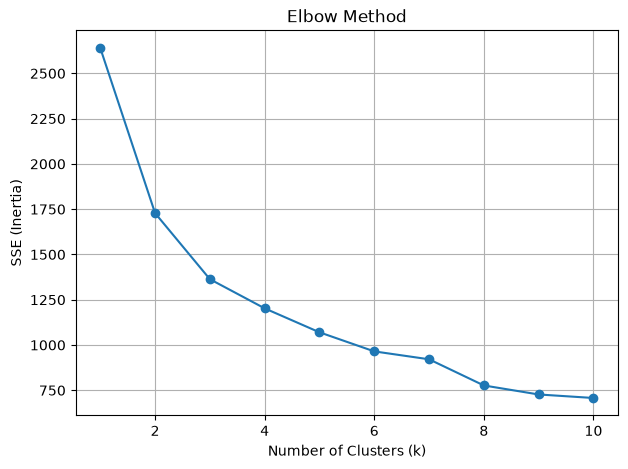

In [144]:
plt.figure(figsize=(7,5))

plt.plot(range(1,11), sse, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters (k)")

plt.ylabel("SSE (Inertia)")

plt.grid(True)

plt.show()

In [145]:
kmeans = KMeans(
    n_clusters=K,
    random_state=RANDOM_STATE,
    n_init="auto"
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = kmeans_labels

print("========== SAMPLE WITH KMEANS CLUSTERS ==========")

print(df.head())

========== SAMPLE WITH KMEANS CLUSTERS ==========
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Cluster  
0     1338.00        0  
1     1776.00        0  
2     3938.25        0  
3     1788.00        3  
4     3938.25        3  


In [146]:
kmeans_silhouette = silhouette_score(
    X_scaled,
    kmeans_labels
)

kmeans_dbi = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

print("========== KMEANS METRICS ==========")

print(f"Silhouette Score : {kmeans_silhouette:.3f}")

print(f"Davies-Bouldin Index : {kmeans_dbi:.3f}")

========== KMEANS METRICS ==========
Silhouette Score : 0.283
Davies-Bouldin Index : 1.270


In [147]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

centers_df = pd.DataFrame(
    centers,
    columns=FEATURES
)

centers_df.index.name = "Cluster"

print("========== CLUSTER CENTERS ==========")

print(centers_df.round(2))

========== CLUSTER CENTERS ==========
            Fresh      Milk   Grocery   Frozen  Detergents_Paper  Delicassen
Cluster                                                                     
0         9202.67   6833.30   9104.12  1326.16           3280.12     1871.76
1         8376.23   2150.65   3160.63  1646.33            779.25      674.02
2        17461.54  13805.60  17524.12  4120.57           5460.56     3583.64
3        22346.70   3409.14   3969.33  5819.60            583.07     1566.95
4         4916.98  10768.85  18350.13  1212.37           7780.02      981.37


## Second Clustering Algorithm – Agglomerative Clustering

For the second clustering method, I selected **Agglomerative Clustering**.

In [148]:
agglomerative = AgglomerativeClustering(
    n_clusters=5
)

agg_labels = agglomerative.fit_predict(X_scaled)

df["Agglomerative_Cluster"] = agg_labels

print("========== AGGLOMERATIVE SAMPLE ==========")

print(df.head())

========== AGGLOMERATIVE SAMPLE ==========
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   
3        1       3  13265.0  1196.0   4221.0  6404.0             507.0   
4        2       3  22615.0  5410.0   7198.0  3915.0            1777.0   

   Delicassen  Cluster  Agglomerative_Cluster  
0     1338.00        0                      4  
1     1776.00        0                      4  
2     3938.25        0                      0  
3     1788.00        3                      3  
4     3938.25        3                      0  


In [149]:
agg_silhouette = silhouette_score(
    X_scaled,
    agg_labels
)

print("========== AGGLOMERATIVE METRIC ==========")

print(f"Silhouette Score : {agg_silhouette:.3f}")

========== AGGLOMERATIVE METRIC ==========
Silhouette Score : 0.218


In [150]:
print("========== COMPARISON ==========")

print(f"K-Means Silhouette Score        : {kmeans_silhouette:.3f}")

print(f"Agglomerative Silhouette Score : {agg_silhouette:.3f}")

if kmeans_silhouette > agg_silhouette:
    print("\nK-Means produced better separated clusters.")
elif agg_silhouette > kmeans_silhouette:
    print("\nAgglomerative Clustering produced better separated clusters.")
else:
    print("\nBoth algorithms produced similar cluster separation.")

========== COMPARISON ==========
K-Means Silhouette Score        : 0.283
Agglomerative Silhouette Score : 0.218

K-Means produced better separated clusters.


In [151]:
sample_clients = df.loc[
    [0, 1, 2],
    [
        "Channel",
        "Region",
        "Fresh",
        "Milk",
        "Grocery",
        "Frozen",
        "Detergents_Paper",
        "Delicassen",
        "Cluster",
        "Agglomerative_Cluster"
    ]
]

print("========== SANITY CHECK ==========")

print(sample_clients)

========== SANITY CHECK ==========
   Channel  Region    Fresh    Milk  Grocery  Frozen  Detergents_Paper  \
0        2       3  12669.0  9656.0   7561.0   214.0            2674.0   
1        2       3   7057.0  9810.0   9568.0  1762.0            3293.0   
2        2       3   6353.0  8808.0   7684.0  2405.0            3516.0   

   Delicassen  Cluster  Agglomerative_Cluster  
0     1338.00        0                      4  
1     1776.00        0                      4  
2     3938.25        0                      0  


In [152]:
df.to_csv(
    OUT_PATH,
    index=False
)

print("Segmented dataset saved successfully!")

print(f"Location: {OUT_PATH}")

Segmented dataset saved successfully!
Location: dataset/segmented_wholesale_customers.csv
